## Steps 1-3 Full Model

### Imports

In [3]:
# Adjust import path
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import os
import h5py
import numpy as np

import opinf

import config
import utils
import step1_generate_data as step1

import matplotlib.pyplot as plt
from ppca_jax import BayesianPPCA
import jax.numpy as jnp
import jax

#### Generate Noisy Data

In [4]:
training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [5]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.40 s.


#### Do a deterministic fit

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.04 s.


INFO:2025-06-25 16:34:01,701:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/anthonypoole/miniconda3/envs/prob_rom/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Weight matrix None
Off diagonal loss -6.9735884e-15


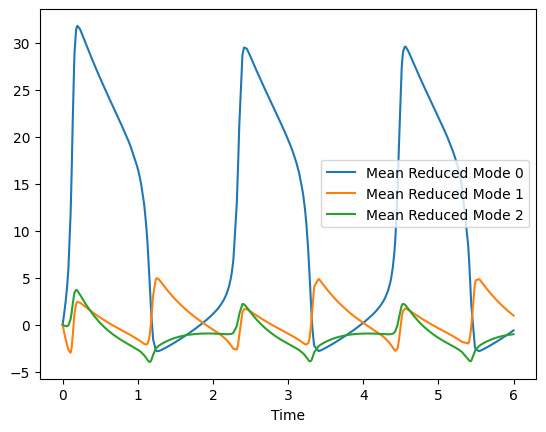

In [6]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

V = basis.entries
W = basis.weights
print(f'Weight matrix', W)

off_diagonal_loss = jnp.sum((V.T @ V) - jnp.eye(V.shape[1])**2)
print("Off diagonal loss", off_diagonal_loss)

for i in range(numPODmodes):
    plt.plot(time_domain_sampled, snapshots_compressed[i], label = f"Mean Reduced Mode {i}")
plt.xlabel('Time')
plt.legend()

### Create helper class to extend BayesianPPCA & Continuous Model

In [7]:
# Fixed implementation of LiftedPPCA with cleaner dimension handling
class LiftedPPCA(BayesianPPCA):
    def __init__(self, *args, **kwargs):
        # Store the original observation dimension before lifting
        super().__init__(*args, **kwargs)
        self.original_obs_dim = None
        
    @staticmethod
    def lift_data(states):
        """
        Lift the data by adding nonlinear features.
        
        Args:
            states: Array of shape (time_dim, param_dim)
        
        Returns:
            Lifted states of shape (time_dim, lifted_param_dim)
        """
        # Split parameters in half (assuming param_dim is even)
        q1, q2 = jnp.split(states, 2, axis=1)  # Split along param dimension
        # Add quadratic features
        return jnp.concatenate([q1, q2, q1**2], axis=1)
    
    def unlift_data(self, lifted_states):
        """
        Extract original states from lifted representation.
        
        Args:
            lifted_states: Array of shape (time_dim, lifted_param_dim)
            
        Returns:
            Original states of shape (time_dim, param_dim)
        """
        # Split into three parts: q1, q2, and q1^2
        q1, q2, _ = jnp.split(lifted_states, 3, axis=1)
        return jnp.concatenate([q1, q2], axis=1)
    
    def fit(self, states, num_samples, warmup_steps, rng_key, penalty=False):
        """
        Fit the model on lifted data.
        
        Args:
            states: Array of shape (param_dim, time_dim) - original format
        """
        # Convert to standard format: (time_dim, param_dim)
        states_standard = states.T
        
        # Store original dimension
        self.original_obs_dim = states_standard.shape[1]
        
        # Lift the data
        lifted_states = self.lift_data(states_standard)
        
        # Update obs_dim for the lifted space
        self.obs_dim = lifted_states.shape[1]
        
        # Fit on lifted data
        super().fit(lifted_states, 
                   num_samples=num_samples, 
                   warmup_steps=warmup_steps, 
                   rng_key=rng_key, 
                   penalty=penalty)
    
    def fit_svi(self, states, rng_key, learning_rate=0.01, num_iterations=5000, penalty=False):
        """
        Fit using SVI on lifted data.
        
        Args:
            states: Array of shape (param_dim, time_dim) - original format
        """
        # Convert to standard format: (time_dim, param_dim)
        states_standard = states.T
        
        # Store original dimension
        self.original_obs_dim = states_standard.shape[1]
        
        # Lift the data
        lifted_states = self.lift_data(states_standard)
        
        # Update obs_dim for the lifted space
        self.obs_dim = lifted_states.shape[1]
        
        # Fit on lifted data
        super().fit_svi(lifted_states,
                       num_iterations=num_iterations,
                       learning_rate=learning_rate,
                       rng_key=rng_key,
                       penalty=penalty)
    
    def compress(self, data):
        """
        Compress original data through lifting then projection.
        
        Args:
            data: Array of shape (param_dim, time_dim) - original format
            
        Returns:
            Compressed data of shape (reduced_dim, time_dim)
        """
        # Convert to standard format: (time_dim, param_dim)
        data_standard = data.T
        
        # Lift the data
        lifted_data = self.lift_data(data_standard)
        
        # Compress using parent method
        compressed = super().compress(lifted_data)
        
        # Convert back to original format: (reduced_dim, time_dim)
        return compressed.T
    
    def decompress(self, latent_data):
        """
        Decompress latent data and unlift.
        
        Args:
            latent_data: Array of shape (reduced_dim, time_dim) - original format
            
        Returns:
            Reconstructed data of shape (param_dim, time_dim)
        """
        # Convert to standard format: (time_dim, reduced_dim)
        latent_standard = latent_data.T
        
        # Decompress to lifted space
        lifted_reconstructed = super().decompress(latent_standard)
        
        # Unlift to get back original representation
        unlifted = self.unlift_data(lifted_reconstructed)
        
        # Convert back to original format: (param_dim, time_dim)
        return unlifted.T

In [8]:
from jax.scipy.special import gammaln

def binom(x, y):
  return jnp.exp(gammaln(x + 1) - gammaln(y + 1) - gammaln(x - y + 1))

def Quadraticckron(state):
    return jnp.concatenate(
                [state[i] * state[: i + 1] for i in range(state.shape[0])],
                axis=0,
            )

def Cubicckron(state):
    state2 = Quadraticckron(state)
    lens = binom(jnp.arange(2, len(state) + 2), 2).astype(int)
    return jnp.concatenate(
        [state[i] * state2[: lens[i]] for i in range(state.shape[0])],
        axis=0,
    )

def khatri_rao(a, b):
    return jnp.vstack([jnp.kron(a[:, k], b[:, k]) for k in range(b.shape[1])]).T

class JaxCompatibleModel(opinf.models.ContinuousModel):
    def __init__(self, operators, solver=None, *args, **kwargs):
        super().__init__(operators, solver, *args, **kwargs)
    
    def _assemble_data_matrix(self, states, inputs):
        """Assemble the data matrix for operator inference."""
        blocks = []
        for i in self._indices_of_operators_to_infer:
            op = self.operators[i]
            if isinstance(op, opinf.operators.ConstantOperator):
                block = jnp.ones((1, jnp.atleast_1d(states).shape[-1]))
            elif isinstance(op, opinf.operators.LinearOperator):
                block = jnp.atleast_2d(states)
            elif isinstance(op, opinf.operators.QuadraticOperator):
                block = Quadraticckron(jnp.atleast_2d(states))
            elif isinstance(op, opinf.operators.CubicOperator):
                block =Cubicckron(np.atleast_2d(states))
            elif isinstance(op, opinf.operators.InputOperator):
                block =jnp.atleast_2d(inputs)
            elif isinstance(op, opinf.operators.StateInputOperator):
                block =khatri_rao(jnp.atleast_2d(inputs), jnp.atleast_2d(states))
            else:
                print("idkK!!", type(op))
            blocks.append(block.T)

        return jnp.hstack(blocks)

### Use a Deterministic Opinf solve to inform operator prior



(512, 400) (512, 400)
idk man


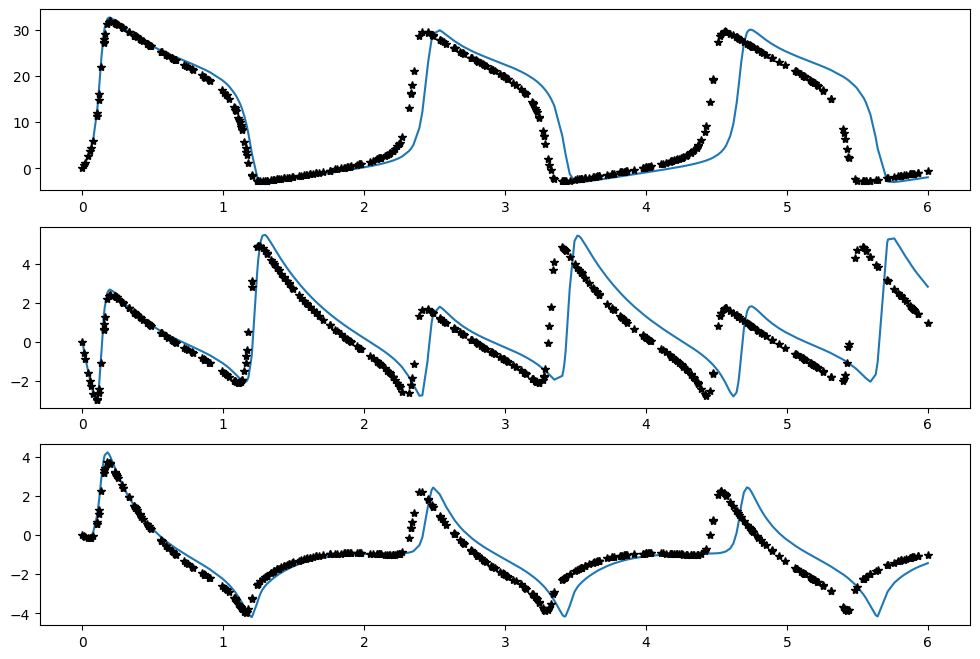

In [9]:
import numpy as np
import random
import time
import opinf

### Generate Prior For operator matrix
input_func = config.ReducedOrderModel.input_func
inputs = input_func(time_domain_sampled) 

rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    model=JaxCompatibleModel(
        operators="cAHBN",
        solver=opinf.lstsq.L2Solver(regularizer=1e-6),
    )
).fit(states=snapshots_sampled, inputs=inputs)

# Solve the ROM over a specified time domain. Make sure it's stable!
Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain, input_func=input_func)
prior_ohat = rom.model.operator_matrix

# Put the operator in the ROM
rom.model._extract_operators(np.array(prior_ohat))

# Plot predictions within training time domains
deter_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0], 
    t=time_domain_sampled, 
    input_func=input_func
)
deter_sol = rom.model.predict_result_
# print(deter_sol.ts.shape)          
# print(deter_sol.message) 

if deter_sol.t.shape[0] == snapshots_sampled.shape[1]:
    print("idk man")
else:
    print(deter_sol.t.shape[0], snapshots_compressed.shape, sep='\n')
    print("Failed to find stable operator, retry")

fig, ax = plt.subplots(3,1, figsize = (12, 8))

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, deter_sol.y[i])

for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

### The model

shapes of data 400 1536
qhat shape (400, 3)
shapes of data 400 1536
qhat shape (400, 3)
shapes of data 400 1536
qhat shape (400, 3)
Starting SVI optimization...
shapes of data 400 1536
qhat shape (400, 3)
Iteration 0: loss = 873726571414814720.0000
Iteration 100: loss = 854341837819740160.0000
Iteration 200: loss = 812019161365479424.0000
Iteration 300: loss = 805030528020381696.0000
Iteration 400: loss = 747227896078139392.0000
Iteration 500: loss = 734895567502573568.0000
Iteration 600: loss = 710425455190081536.0000
Iteration 700: loss = 683466598308118528.0000
Iteration 800: loss = 665137395875708928.0000
Iteration 900: loss = 649617720530173952.0000
Iteration 1000: loss = 618409869682147328.0000
Iteration 1100: loss = 607666953884008448.0000
Iteration 1200: loss = 591723348086489088.0000
Iteration 1300: loss = 581574306006302720.0000
Iteration 1400: loss = 557522111191580672.0000
Iteration 1500: loss = 545531627653038080.0000
Iteration 1600: loss = 541299435599036416.0000
Iteratio

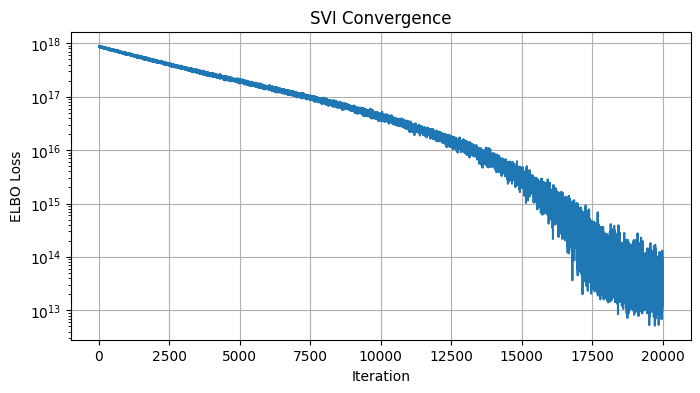

In [10]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from things.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 
import optax

kernel = RBFKernel()

# Fix the PPCA
def model(time, data, O_mean, chi, normalization=1e-4, catch_unstable=False):
    num_time_steps, obs_dim = time.shape[0], data.shape[1]
    print('shapes of data', num_time_steps, obs_dim)

    ### ------- PPCA ------- ###
    # Priors
    # Loading matrix W with appropriate scale
    V = numpyro.sample("V", dist.Normal(
        jnp.zeros((obs_dim, numPODmodes)),
        jnp.ones((obs_dim, numPODmodes))
    ).to_event(2))

    # Penalty for orthogonal bases
    strength = 500
    loss = jnp.sum(((V.T @ V) - jnp.eye(V.shape[1]))**2)
    numpyro.factor("orth_penalty", -strength * loss)
    
    # Mean parameter
    qbar = numpyro.sample("qbar", dist.Normal(
        jnp.zeros(obs_dim),
        jnp.ones(obs_dim) * 2.0
    ).to_event(1))
    
    # Noise variance (use log-normal to ensure positivity)
    log_sigma2 = numpyro.sample("log_sigma2", dist.Normal(0.0, 1.0))
    sigma2 = jnp.exp(log_sigma2)
    
    # Latent variables for each observation
    with numpyro.plate("data", num_time_steps):
        qhat = numpyro.sample("qhat", dist.Normal(
            jnp.zeros(numPODmodes),
            jnp.ones(numPODmodes)
        ).to_event(1))
        
        # Observation model: t = W @ x + μ + ε
        mean = jnp.matmul(qhat, V.T) + qbar
        
        # Likelihood with isotropic Gaussian noise
        numpyro.sample("obs", dist.Normal(
            mean,
            jnp.sqrt(sigma2) * jnp.ones_like(mean)
        ).to_event(1), obs=data)
    
    print('qhat shape', qhat.shape)
    qhat = qhat.T
    
    # assume O_mean has shape (n_modes, n_coeffs)
    base_scale = 1e-3      # loose prior on constant/linear
    highord_scale = 1e-8   # tight prior on quad/cubic

    # build a scale matrix of same shape as O_mean
    scales = jnp.ones_like(O_mean) * highord_scale
    scales = scales.at[:, :4].set(base_scale)      # first 4 columns get base_scale

    O = numpyro.sample('oi',
                    dist.Normal(O_mean, scales))
     
    Xs = []
    Ls = []
    Vars = []
    noises = []
    Kyys = []
    
    for i in range(numPODmodes):
        # Priors for hyperparameters
        lengthscale = numpyro.sample(f"lengthscale{i}", dist.LogNormal(0.0, 1.0))
        Ls.append(lengthscale)
        variance = numpyro.sample(f"variance{i}", dist.LogNormal(0.0, 1.0))
        Vars.append(variance)
        noise = numpyro.sample(f"noise{i}", dist.LogNormal(-2.0, 1.0))
        noises.append(noise)
        
        # Compute kernel matrix
        K = kernel(time, time, lengthscale, variance)
        
        # Add noise to diagonal
        K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
        
        # GP prior over function values
        x = numpyro.sample(f"f{i}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
        
        # Likelihood
        with numpyro.plate(f"data{i}", num_time_steps):
            numpyro.sample(f"y{i}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i])
    
        # Gradient matching part
        Kyy = get_c_phi(lengthscale, variance, time, normalization)
        Kyys.append(Kyy)
        Xi = numpyro.sample(f'Xi{i}',
                            dist.MultivariateNormal(
                                jnp.zeros(num_time_steps),
                                Kyy 
                            ))  
        Xs.append(Xi)
        
        obs_cov = chi * jnp.eye(num_time_steps)
        
        numpyro.sample(f'Yi{i}',
                    dist.MultivariateNormal(Xi, obs_cov),
                    obs=qhat[i])
        
    Xs = jnp.array(Xs)
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs) @ O.T
    
    for i in range(numPODmodes):
        lengthscale = Ls[i]
        variance = Vars[i]
        Kyy = Kyys[i]
        Xi = Xs[i]
        
        # Cache inverse computation
        Kyy_inv = jnp.linalg.solve(Kyy, jnp.eye(num_time_steps))
        Ds = get_dash_c_phi(lengthscale, variance, time) @ Kyy_inv
        CDashs = get_c_phi_dash(lengthscale, variance, time)
        DashCs = get_dash_c_phi(lengthscale, variance, time)
        CPhis = get_c_phi(lengthscale, variance, time, nugget=1e-4)
        CDoubleDashs = get_c_phi_double_dash(lengthscale, variance, time)
        # Use Cholesky decomposition for more stable inverse
        CPhis_chol = jnp.linalg.cholesky(CPhis)
        A = CDoubleDashs - DashCs @ jax.scipy.linalg.cho_solve((CPhis_chol, True), CDashs)
        mu_zi = Ds @ Xi
        gamma = 1e2*[5,1,1][i]
        constraint_cov = A + gamma * jnp.eye(num_time_steps)
        
        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(mu_zi, constraint_cov),
            obs=f_Xi_ohat.T[i]
        )

# Create autoguide - this automatically creates variational distributions
guide = autoguide.AutoNormal(model)
# You can also use more sophisticated guides like AutoLowRankMultivariateNormal
guide = autoguide.AutoLowRankMultivariateNormal(model, rank=50)

# Setup optimizer
schedule = optax.exponential_decay(
    init_value=1e-3,
    transition_steps=1000,
    # decay_rate=0.5,
    decay_rate=.25,
    staircase=True
)
optimizer = Adam(step_size=schedule)
optimizer = Adam(step_size=0.0005)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Lift the data
lifted_data = LiftedPPCA.lift_data(snapshots_sampled.T)

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_sampled[:, None], 
                     data=lifted_data,
                     O_mean=prior_ohat,
                     chi=1e-6)

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled[:, None], 
                                  data=lifted_data,
                                  O_mean=prior_ohat,
                                  chi=1e-6)
    return svi_state, loss

# Training loop
num_iterations = 20000  # Adjust as needed
losses = []

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=100)
samples = predictive(rng_key,
                     time=time_domain_sampled[:, None], 
                     data=lifted_data, 
                     O_mean=prior_ohat,
                     chi=1e-6)

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

In [11]:
samples.keys()

dict_keys(['V', 'Xi0', 'Xi1', 'Xi2', '_auto_latent', 'f0', 'f1', 'f2', 'lengthscale0', 'lengthscale1', 'lengthscale2', 'log_sigma2', 'noise0', 'noise1', 'noise2', 'oi', 'qbar', 'qhat', 'variance0', 'variance1', 'variance2'])

In [12]:
def compute_sample_gp(ls, var, noise, x_train, y_train, x_test, normalization = 1e-4):
    n_train = x_train.shape[0]
    # Kernel matrices
    K_train = kernel(x_train, x_train, ls, var)
    K_train_noise = K_train + (noise + normalization) * jnp.eye(n_train)
    K_test_train = kernel(x_test, x_train, ls, var)
    K_test = kernel(x_test, x_test, ls, var)
    
    # GP posterior predictive
    # Cholesky decomposition
    L = jnp.linalg.cholesky(K_train_noise)
    
    # Solve for alpha = K_train_noise^{-1} @ y_train
    alpha = jax.scipy.linalg.cho_solve((L, True), y_train)
    
    # Predictive mean
    mean = K_test_train @ alpha
    
    # Predictive covariance
    v = jax.scipy.linalg.solve_triangular(L, K_test_train.T, lower=True)
    cov = K_test - v.T @ v
    
    # Sample from predictive distribution
    cov_noise = cov + normalization * jnp.eye(n_test)
    L_pred = jnp.linalg.cholesky(cov_noise)
    
    # Generate sample
    eps = np.random.normal(loc = np.zeros(n_test), scale = np.ones(n_test))
    sample = mean + L_pred @ eps

    return sample

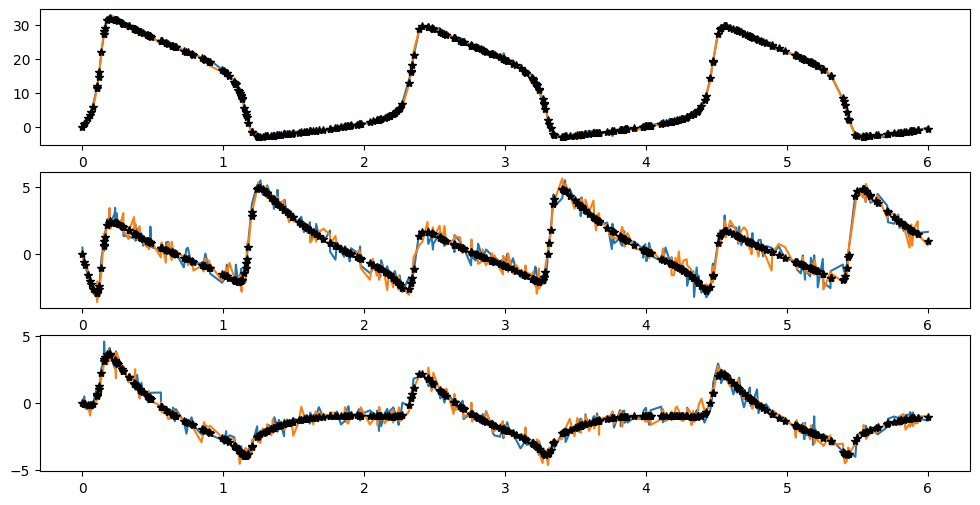

In [13]:
mean_lengthscales = [samples[f'lengthscale{i}'].mean() for i in range(numPODmodes)]
median_lengthscales = [np.median(samples[f'lengthscale{i}']) for i in range(numPODmodes)]
mean_variance = [samples[f'variance{i}'].mean() for i in range(numPODmodes)]
median_variance = [np.median(samples[f'variance{i}']) for i in range(numPODmodes)]
mean_noise = [samples[f'noise{i}'].mean() for i in range(numPODmodes)]
median_noise = [np.median(samples[f'noise{i}']) for i in range(numPODmodes)]

fig, ax = plt.subplots(3,1, figsize = (12,6))
X_train = time_domain_sampled[:,None]
X_test = X_train
y_trains = snapshots_compressed

for i in range(numPODmodes):
    ls = mean_lengthscales[i]
    var = mean_variance[i]
    noise = mean_noise[i]
    normalization = 1e-4
    n_train = X_train.shape[0]
    n_test = n_train
    y_train = y_trains[i]

    mean_sample = compute_sample_gp(ls, var, noise, X_train, y_train, X_test)
    median_sample = compute_sample_gp(median_lengthscales[i], median_variance[i], median_noise[i], X_train, y_train, X_test) 

    ax[i].plot(time_domain_sampled, mean_sample, label = 'Mean Samples')
    ax[i].plot(time_domain_sampled, median_sample, label = 'Median Samples')
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

##### Latent States X's

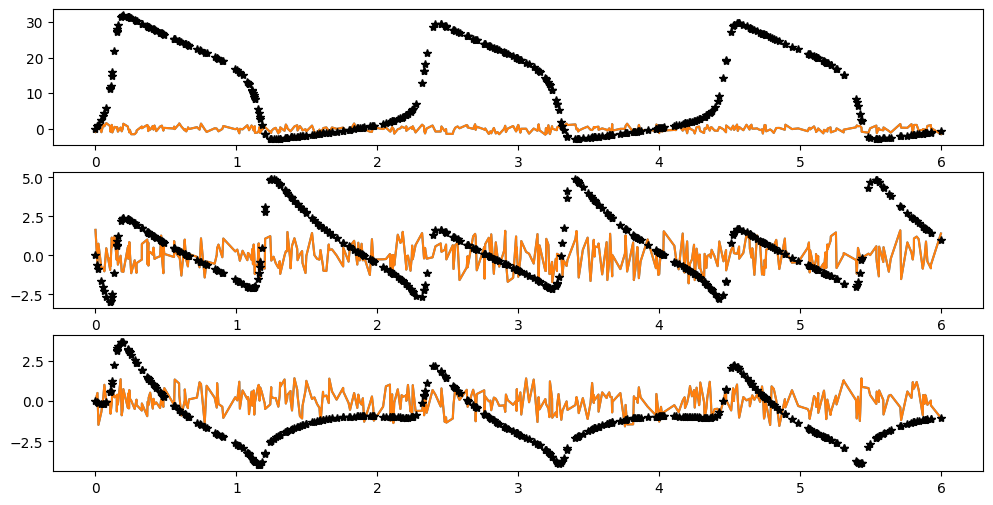

In [14]:
### Eval X's
mean_X = np.stack([samples[f'Xi{i}'].mean(axis=0) for i in range(numPODmodes)])
median_X = np.stack([np.median(samples[f'Xi{i}'], axis=0) for i in range(numPODmodes)])

fig, ax = plt.subplots(3,1, figsize = (12,6))
for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, mean_X[i], label = "Mean")
    ax[i].plot(time_domain_sampled, median_X[i], label = "Median")
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

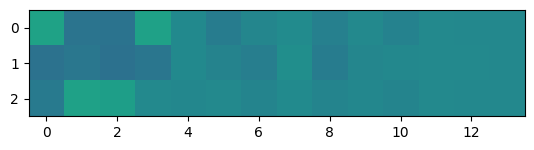

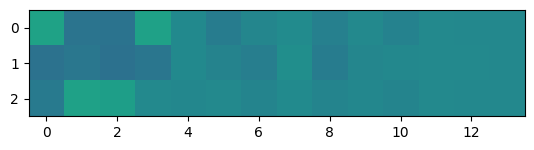

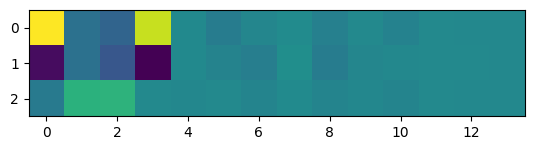

In [15]:
mean_oi = samples['oi'].mean(axis=0)
median_oi = jnp.median(samples['oi'], axis=0)

minimum = min(median_oi.min(), prior_ohat.min(), mean_oi.min())
maximum = max(median_oi.max(), prior_ohat.max(), mean_oi.max())
plt.imshow(median_oi, vmin = minimum, vmax = maximum)
plt.show()
plt.imshow(mean_oi, vmin = minimum, vmax = maximum)
plt.show()
plt.imshow(prior_ohat, vmin = minimum, vmax = maximum)
plt.show()

(-5.0, 10.0)

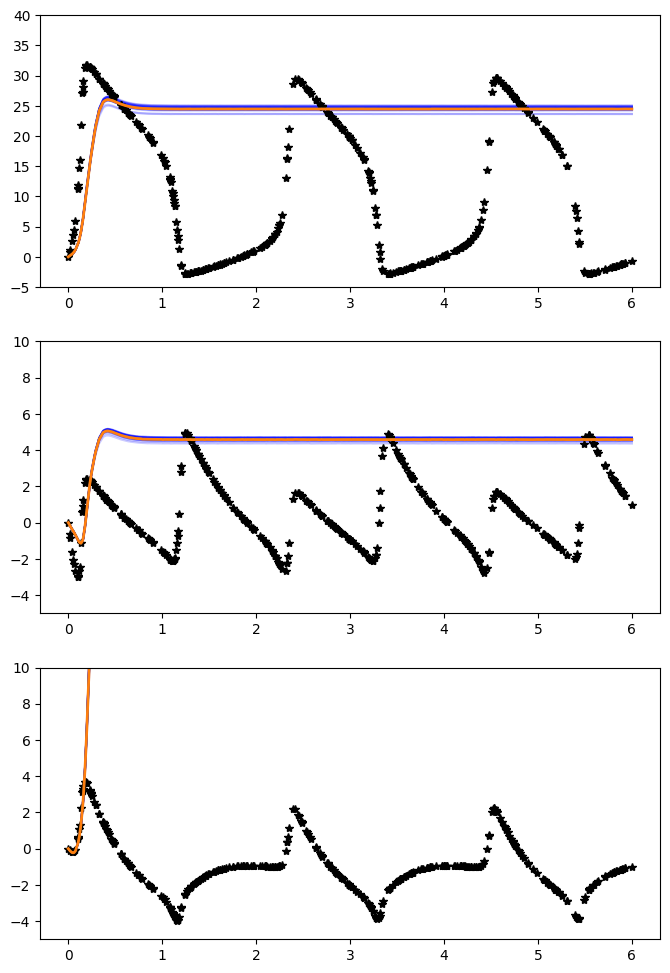

In [16]:
import random

fig, ax = plt.subplots(3,1, figsize = (8, 12))

num_pulls = 25
for i in range(num_pulls):
    rand_idx = random.randint(0, len(samples['oi']))
    o = samples['oi'][rand_idx]
    # Put the operator in the ROM
    rom.model._extract_operators(np.array(o))

    # Plot predictions within training time domains
    deter_pred = rom.model.predict(
        state0=snapshots_compressed[:, 0], 
        t=time_domain_sampled, 
        input_func=input_func
    )
    deter_sol = rom.model.predict_result_
    # print(deter_sol.ts.shape)          
    # print(deter_sol.message) 

    if deter_sol.t.shape[0] == snapshots_sampled.shape[1]:
        pass
    else:
        print(deter_sol.t.shape[0], snapshots_compressed.shape, sep='\n')
        print("Failed to find stable operator, retry")

    for i in range(numPODmodes):
        ax[i].plot(deter_sol.t, deter_sol.y[i], color = 'blue', alpha = .2)

for i in range(numPODmodes):
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')


rom.model._extract_operators(np.array(mean_oi))
deter_pred = rom.model.predict(
        state0=snapshots_compressed[:, 0], 
        t=time_domain_sampled, 
        input_func=input_func
    )
deter_sol = rom.model.predict_result_

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, deter_sol.y[i])

rom.model._extract_operators(np.array(median_oi))
deter_pred = rom.model.predict(
        state0=snapshots_compressed[:, 0], 
        t=time_domain_sampled, 
        input_func=input_func
    )
deter_sol = rom.model.predict_result_

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, deter_sol.y[i], lw = 2)

ax[0].set_ylim(-5,40)
ax[1].set_ylim(-5,10)
ax[2].set_ylim(-5,10)